<a href="https://colab.research.google.com/github/sahilshirsat2004-coder/CSL701-CE45_Machine-Learning-Lab/blob/main/experiment/pract2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name : Sahil Ganesh Shirsat
Roll No: CE45

Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


Step 2: Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Step 3: Inspect Dataset

In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.00000

Step 4: Data Preprocessing

In [4]:
df = df[['horsepower', 'mpg']]

df = df.dropna()

print(df.head())

   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  17.0


Step 5: Exploratory Data Analysis
Scatter Plot

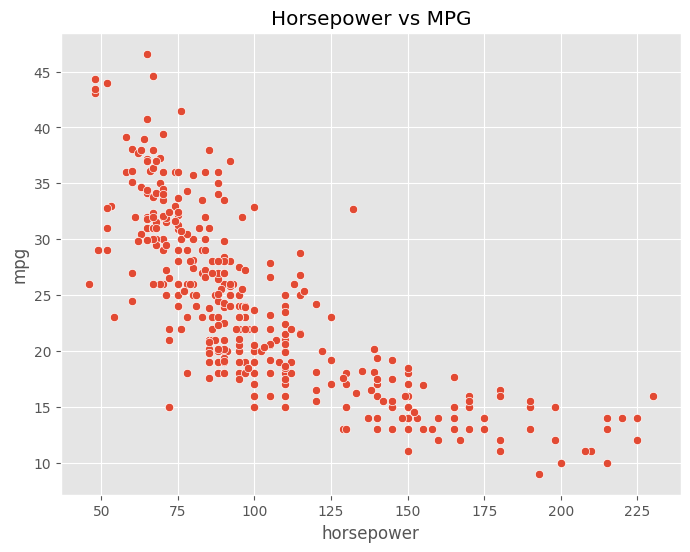

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title("Horsepower vs MPG")
plt.show()

Correlation

In [6]:
corr = df['horsepower'].corr(df['mpg'])

print("Correlation =", corr)

Correlation = -0.7784267838977756


Step 6: Prepare Data for OLS

In [8]:
X = df['horsepower'].values

Y = df['mpg'].values

X = X.reshape(-1,1)

ones = np.ones((len(X),1))

X_bias = np.hstack((ones,X))

Step 7: Compute OLS Coefficients

In [9]:
W = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("Intercept =", W[0])

print("Slope =", W[1])

Intercept = 39.9358610211705
Slope = -0.15784473335365387


Step 8: Predict MPG

In [10]:
Y_pred = X_bias @ W

print(Y_pred[:10])

[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


Step 9: Compute Residuals

In [11]:
residuals = Y - Y_pred

print(residuals[:10])

[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Step 10: Evaluation Metrics
SSE

In [12]:
SSE = np.sum((Y - Y_pred)**2)

print("SSE =", SSE)

SSE = 9385.915871932419


MSE

In [13]:
MSE = np.mean((Y - Y_pred)**2)

print("MSE =", MSE)

MSE = 23.943662938603108


R² Score

In [14]:
SST = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SSE/SST)

print("R² =", R2)

R² = 0.6059482578894348


Step 11: Regression Line

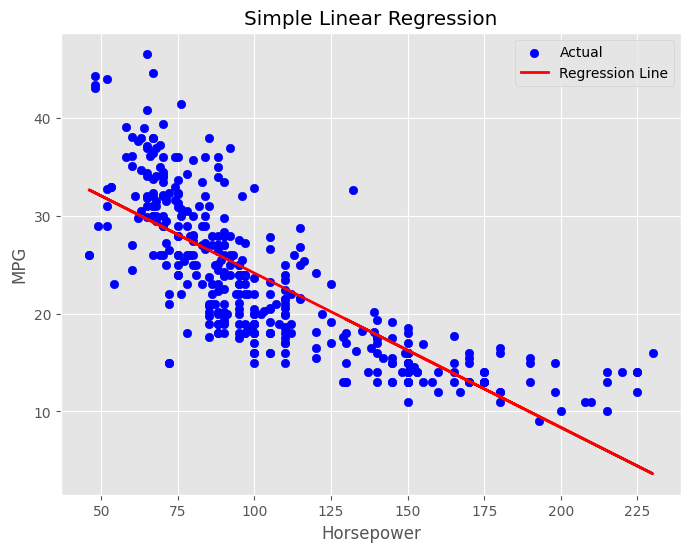

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(X, Y, color='blue', label='Actual')

plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Horsepower")

plt.ylabel("MPG")

plt.title("Simple Linear Regression")

plt.legend()

plt.show()

Step 12: Residual Plot

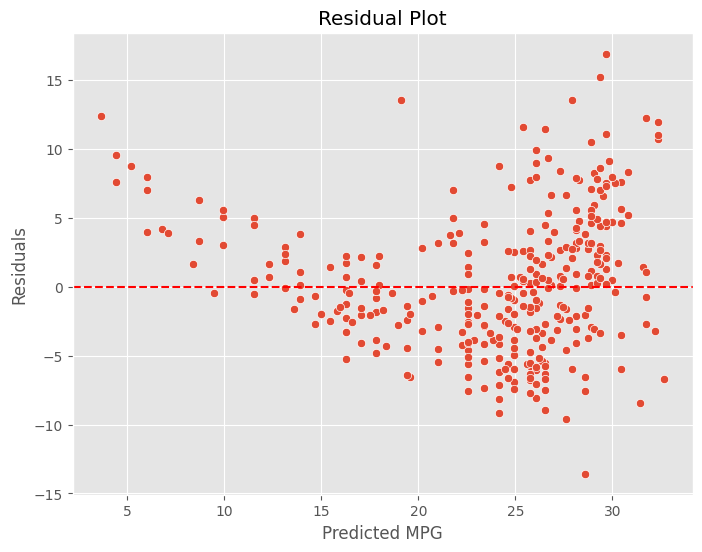

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=Y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted MPG")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Result

The Simple Linear Regression model was successfully implemented using the Ordinary Least Squares (OLS) method. The regression equation obtained was:

MPG=39.94−0.158×Horsepower

The model showed a negative relationship between horsepower and fuel efficiency, indicating that vehicles with higher horsepower generally have lower MPG.

Conclusion

The experiment successfully implemented Simple Linear Regression using the Ordinary Least Squares (OLS) method. The Auto MPG dataset was loaded, cleaned, and analyzed using exploratory data analysis. A strong negative correlation was observed between horsepower and MPG. The OLS algorithm was used to compute the regression coefficients manually, and the model was evaluated using SSE, MSE, and R² metrics. The regression line and residual plots confirmed the model's behavior and predictive capability, demonstrating that horsepower is a useful predictor of fuel efficiency.